#  Problem 2

## Problem
$$
\begin{align*}
u(x,y) = (x+1)^{5/2}(y+1)^{5/2}-(x+1)(y+1)^{5/2}-(x+1)^{5/2}(y+1)+(x+1)(y+1)
\end{align*}
$$

From the Paper:

As in the previous problem, the dominant parameter is the number of circles M. Table III
presents relative errors for the Dirichlet and Neumann problems in a discretization with a
constant number of Fourier coefficients N = 64. Note that quadratic and cubic convergence,
resulting from distinct integration schemes, still holds.


# Imports

In [1]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sp

import os, sys

# Main project root
repo_root = r"C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)


from Tests.JCP_Paper_Comparisons.JCP_Helpers import (
    get_problem_functions,
    run_table_2,
    display_table_varying_M
)




# Problem Setup

In [2]:
# Problem Setup  — Problem 2 (Borges–Daripa JCP)

# Radius
R = 1.0

# Radial mesh type: keep radial grid uniform here
rad_unif = 1

x, y = sp.symbols('x y')
u_sym = (x + 1.0)**2.5 * (y + 1.0)**2.5 - (x + 1.0) * (y + 1.0)**2.5 - (x + 1.0)**2.5 * (y + 1.0) + (x + 1.0) * (y + 1.0)
u, f, g_dirichlet, g_neumann = get_problem_functions(u_sym, x, y)

# N and M values (Problem 2: Table 3 uses fixed N = 64, varying M)
M_values = [64, 128, 256, 512, 1024, 2048]
N_fixed  = 64

# ----------------------------------------------------------
# Methods to test
# ----------------------------------------------------------
methods = [
    dict(
        name="uniform_fft",
        label="Uniform Mesh",
        azu_unif=2,
        mesh_kind=None,
        use_nudft=None,
    ),
]

BC_MAP = {
    "dirichlet": 1,
    "neumann": 2,
}

QUAD_MAP = {
    "trapezoidal": 1,
    "simpson": 2,
}

# Run Code, table 3

In [3]:
df_table3 = run_table_2(methods, N_fixed, M_values, u, f, g_dirichlet, g_neumann, BC_MAP, QUAD_MAP, rad_unif, R)


C:\Users\charl\OneDrive\Documents\GitHub\NUFFTRR_Poisson\Poisson_Solver\cpu_solver\radial\radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]


# View Results

In [4]:
display_table_varying_M(df_table3, methods, M_values, "TABLE 3 (Problem 2)")



Uniform Mesh : TABLE 3 (Problem 2)


Trapezoidal rule                             Simpson rule           \
            Dirichlet            Neumann             Dirichlet            
            L_inf_rel   L2_rel L_inf_rel   L2_rel    L_inf_rel   L2_rel   
M                                                                         
64            3.2e-05  1.0e-04   2.2e-04  4.8e-04      3.1e-06  9.3e-06   
128           8.0e-06  2.5e-05   5.3e-05  1.2e-04      4.1e-07  1.1e-06   
256           2.0e-06  6.2e-06   1.3e-05  2.9e-05      5.5e-08  1.4e-07   
512           4.9e-07  1.5e-06   3.3e-06  7.2e-06      7.4e-09  1.8e-08   
1024          1.2e-07  3.8e-07   8.2e-07  1.8e-06      1.1e-09  2.2e-09   
2048          3.1e-08  9.6e-08   2.0e-07  4.5e-07      3.3e-10  3.0e-10   

                         
       Neumann           
     L_inf_rel   L2_rel  
M                        
64     9.8e-07  1.5e-06  
128    1.5e-07  1.8e-07  
256    2.3e-08  2.4e-08  
512    3.1e-09  3.2e-09  
1024   9.9e-10  8.2e-10  
2048   9.4e-10  7.0e-10

## Figures from the original paper

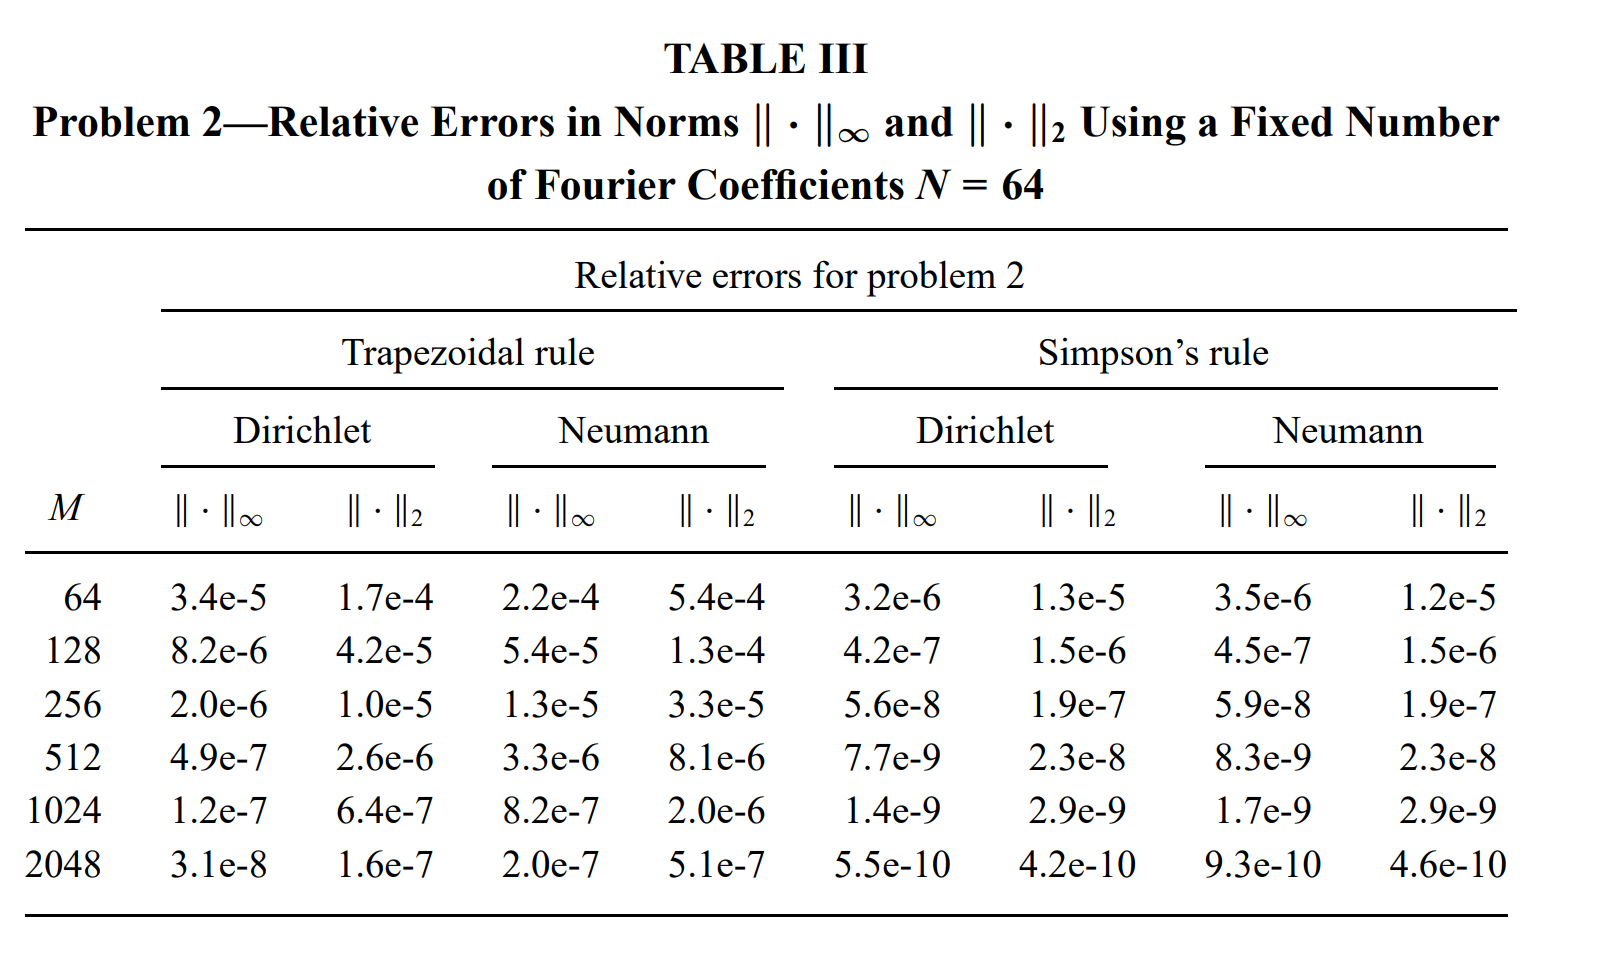